# ME 3300 Prelab 02 Walkthrough — New Python Skills

Welcome back! Lab 02 asks you to analyze **eleven** data files, find an event
in a signal, and simulate a differential equation. This walkthrough teaches
every *new* Python skill those tasks require, one small step at a time.

Skills from Lab 01 (loading CSVs, `polyfit`, plot formatting) are assumed —
keep your Lab 01 notebook handy.

**How to use this notebook:** run it cell by cell (`Shift+Enter`), reading as
you go. Boxes marked **CHECKPOINT** ask for values you must report in the
Prelab 02 quiz on Canvas.

> Select your `.venv` kernel before running (top-right **Select Kernel** →
> your `ME3300` environment).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

print('imports OK')

imports OK


## 1. `for` loops — doing the same thing many times

In Lab 02 you will compute the mean of 11 data files. You could copy-paste
`pd.read_csv(...)` eleven times... but many times if you catch yourself
copy-pasting code, a loop is the better tool.

A `for` loop runs its indented body once for each element of a sequence:

In [2]:
angles = [-90, -45, 0, 45, 90]

for angle in angles:
    print(f"angle is {angle} degrees")

angle is -90 degrees
angle is -45 degrees
angle is 0 degrees
angle is 45 degrees
angle is 90 degrees


Note the structure: the `for ... in ...:` line ends with a colon, and
everything **indented** below it is the loop body. Indentation is not
decorative in Python, it defines what is inside the loop.

### `enumerate` — a loop with a counter

Often you need both the *value* and its *position* (for storing results in
order). `enumerate` provides both:

In [5]:
results = np.zeros(len(angles))    # empty array to fill

for i, angle in enumerate(angles):
    results[i] = angle * 2         # store each result in slot i

print(results)

[-180.  -90.    0.   90.  180.]


**CHECKPOINT 1:** Change the loop above to store `angle**2` instead and
re-run. What is `results[3]`? Report this value in the Canvas quiz.

## 2. f-strings — building text from variables

You saw f-strings printed above. An **f-string** is a string prefixed with
`f` where anything inside `{ }` gets replaced by a variable's value. You will
use them to build *filenames* and *plot annotations*:

In [6]:
name = 'Ada'
value = 3.14159

print(f"{name}'s value is {value}")
print(f"{name}'s value to 2 decimals is {value:.2f}")   # format spec after :

Ada's value is 3.14159
Ada's value to 2 decimals is 3.14


### A one-line conditional

Lab 02's files are named `Ang_n45Deg.csv` for −45° and `Ang_p45Deg.csv` for
+45°. To pick `'n'` or `'p'` automatically, Python has a compact
conditional expression:

In [8]:
for angle in [-30, 30]:
    sign = 'n' if angle < 0 else 'p'
    filename = f'Ang_{sign}{abs(angle)}Deg.csv'
    print(filename)

Ang_n30Deg.csv
Ang_p30Deg.csv


**CHECKPOINT 2:** What filename does this code produce for
`angle = -70`? (Predict first, then test.)

## 3. Practice data — and `np.savetxt`

Let's create three small practice files to loop over, using `np.savetxt`
(also how you'll save your calibration coefficients in lab):

In [10]:
rng = np.random.default_rng(42)   # seeded so everyone gets the same data

import os
os.makedirs('practice_data', exist_ok=True)

true_means = {-30: 1.2, 0: 1.65, 30: 2.1}
for angle, mu in true_means.items():
    t = np.arange(0, 5, 0.05)                    # 20 Hz for 5 s
    v = mu + rng.normal(0, 0.01, t.size)
    sign = 'n' if angle < 0 else 'p'
    np.savetxt(f'practice_data/Ang_{sign}{abs(angle)}Deg.csv',
               np.column_stack([t, v]), delimiter=',',
               header='Time (s),Channel 1 (V)', comments='')
print('practice files written')

practice files written


## 4. `.iloc` — selecting DataFrame data by position

`pd.read_csv` gives you a DataFrame. In Lab 01 you selected columns by *name*
(`df['column']`). But exported files don't always have tidy, predictable
names — WaveForms column headers change with export settings. `.iloc` selects
by **position** instead: `df.iloc[rows, columns]`, counting from 0.

In [11]:
df = pd.read_csv('practice_data/Ang_p30Deg.csv')
df.head()    # ALWAYS look at your data after loading!

,Time (s),Channel 1 (V)
0,0.00,2.103376
1,0.05,2.114075
2,0.10,2.100906
3,0.15,2.106439
4,0.20,2.079498


In [12]:
time_col = df.iloc[:, 0]     # all rows, first column  (time)
volt_col = df.iloc[:, 1]     # all rows, second column (voltage)

print(f"mean voltage = {volt_col.mean():.4f} V")
print(f"first 3 voltages:\n{volt_col.iloc[:3]}")

mean voltage = 2.0994 V
first 3 voltages:
0    2.103376
1    2.114075
2    2.100906
Name: Channel 1 (V), dtype: float64


`.values` converts a DataFrame column to a plain numpy array — do this
before math-heavy work:

```python
volt = df.iloc[:, 1].values
```

### Putting it together: loop over all three practice files

In [13]:
practice_angles = np.array([-30, 0, 30])
practice_means  = np.zeros(len(practice_angles))

for i, angle in enumerate(practice_angles):
    sign = 'n' if angle < 0 else 'p'
    df = pd.read_csv(f'practice_data/Ang_{sign}{abs(angle)}Deg.csv')
    practice_means[i] = df.iloc[:, 1].mean()

print(np.round(practice_means, 4))

[1.1995 1.6499 2.0994]


**CHECKPOINT 3:** Report the mean voltage of the −30° practice file
(first element printed above) to 4 decimal places.

This loop is 90% of your Lab 02 calibration code — in lab you'll simply have
more angles and a `skiprows=` argument for the WaveForms metadata lines
(count them in *your* file first!).

## 5. Finding events: `np.diff` and `np.argmax`

In lab, your swing recording will start with the pendulum *held still*, then
released. You'll trim the data so $t=0$ is the release. 

Strategy: the signal barely changes while held, then changes fast. `np.diff` computes the change
between adjacent samples:

In [16]:
# Fake "held then released" signal
t_sig = np.arange(0, 4, 0.01)
sig   = np.where(t_sig < 1.5, 2.0, 2.0 + 0.8*np.sin(6*(t_sig-1.5)))
sig  += rng.normal(0, 0.001, t_sig.size)

d = np.abs(np.diff(sig))
print(f"typical change while held:   {d[:100].mean():.5f}")
print(f"biggest change overall:      {d.max():.5f}")

typical change while held:   0.00103
biggest change overall:      0.05011


release detected at t = 1.50 s


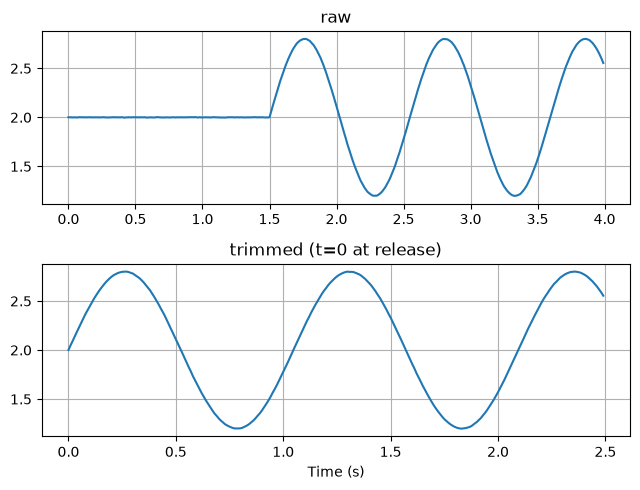

In [17]:
# The comparison d > 0.01 gives an array of True/False.
# np.argmax returns the index of the FIRST True (True counts as 1).
idx0 = np.argmax(d > 0.01)
print(f"release detected at t = {t_sig[idx0]:.2f} s")

# Trim: keep everything from idx0 on, and restart the clock
t_trim   = t_sig[idx0:] - t_sig[idx0]
sig_trim = sig[idx0:]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6.5, 5), sharey=True)
ax1.plot(t_sig, sig); ax1.set_title('raw'); ax1.grid(True)
ax2.plot(t_trim, sig_trim); ax2.set_title('trimmed (t=0 at release)'); ax2.grid(True)
ax2.set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

**CHECKPOINT 4:** At what time (in the *raw* signal) was the release
detected? Report to 2 decimal places.

If a threshold ever misfires on your real data, *plot* `d` and look at it —
choosing thresholds by eye is normal engineering practice.

## 6. Defining functions with `def`

So far you've only *called* functions. To simulate an ODE you must *write*
one: a function that the solver will call. The pattern:

```python
def function_name(inputs):
    ...compute...
    return outputs
```


In [18]:
def circle_area(r):
    return np.pi * r**2

print(f"area of r=2 circle: {circle_area(2):.4f}")

area of r=2 circle: 12.5664


## 7. Simulating an ODE with `solve_ivp`

Lab 02's pendulum obeys a second-order ODE:

$$\ddot\theta + 2\zeta\omega_n\dot\theta + \omega_n^2\sin(\theta) = 0$$

`scipy.integrate.solve_ivp` (Python's `ode45`) only accepts systems of
**first-order** equations, so we introduce $\omega = \dot\theta$ and write:

$$\frac{d\theta}{dt} = \omega, \qquad
\frac{d\omega}{dt} = -2\zeta\omega_n\omega - \omega_n^2\sin(\theta)$$

The state is the vector $y = [\theta, \omega]$. Our job: write a function
that receives $(t, y)$ and returns $[\dot\theta, \dot\omega]$.

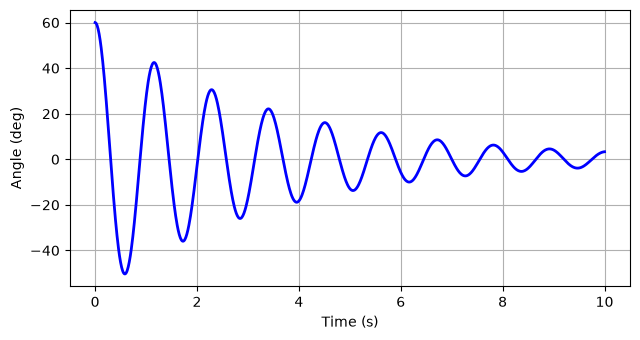

In [19]:
from scipy.integrate import solve_ivp

L, g = 0.30, 9.81
omega_n = np.sqrt(g / L)
zeta = 0.05

def pendulum_ode(t, y):
    theta, omega = y                 # unpack the state vector
    dtheta_dt = omega
    domega_dt = -2*zeta*omega_n*omega - omega_n**2*np.sin(theta)
    return [dtheta_dt, domega_dt]

# Integrate 10 s from a 60-degree release at rest
theta0, omega0 = np.radians(60), 0.0
t_eval = np.linspace(0, 10, 1000)
sol = solve_ivp(pendulum_ode, (0, 10), [theta0, omega0],
                t_eval=t_eval, max_step=0.005)

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.plot(sol.t, np.degrees(sol.y[0]), 'b-', linewidth=2)
ax.set_xlabel('Time (s)'); ax.set_ylabel('Angle (deg)')
ax.grid(True)
plt.tight_layout()
plt.show()

Read the call signature carefully — you will reuse it in lab:

- `pendulum_ode` — your derivative function
- `(0, 10)` — time span (start, stop)
- `[theta0, omega0]` — initial state
- `t_eval` — times where you want the solution reported
- `max_step=0.005` — caps step size so fast oscillations aren't skipped

Results: `sol.t` (times) and `sol.y[0]` ($\theta$, radians — first state
variable). `sol.y[1]` would be $\omega$.

**CHECKPOINT 5:** Change `zeta` to `0.15` and re-run. Approximately what is
the peak angle (in degrees) of the *second* positive swing? Report to the
nearest 5 degrees.

**CHECKPOINT 6:** With `zeta` back at `0.05`, change `L` to `0.60`. Does the
pendulum swing faster or slower? Why? (One sentence — relate to
$\omega_n = \sqrt{g/L}$.)

## Done!

You now have every new tool Lab 02 needs:

| Skill | Where you'll use it in lab |
|---|---|
| `for` + `enumerate` | averaging 11 calibration files |
| f-strings + conditional | building `Ang_p/nXXDeg.csv` filenames; annotating plots |
| `.iloc` / `.values` | extracting time & voltage from WaveForms CSVs |
| `np.diff` + `np.argmax` | trimming the swing to the release moment |
| `def` | writing the pendulum ODE function |
| `solve_ivp` | simulating the model to overlay on your data |

Report your checkpoint values in the **Prelab 02 quiz on Canvas** before your
lab session.